In [1]:
import cce_library as cce
import matplotlib.pyplot as plt
import numpy as np

In [11]:
library, history = cce.build_library(
    fccd_mm=0.95,
    alpha=1e-10,
    dx_um=1,
    ncharges=30,
    save_history=True
)

100%|██████████| 950/950 [20:16<00:00,  1.28s/it]


In [12]:
depth = library.depth_mm
CCE = library.cce

In [63]:
np.savez(
    "CCE_library_fast.npz",

    depth_mm=library.depth_mm,

    cce=library.cce,

    response=library.response,

    fccd_mm=library.fccd_mm,

    alpha=library.alpha,

    dx_um=library.dx_um
)


In [64]:
# ==========================
# Salva history
# ==========================

np.savez(
    "Charge_history_fast.npz",

    depth_mm=history.depth_mm,

    lifetime_ns=history.lifetime_ns,

    collected=history.collected,

    trapped=history.trapped
)


print("Salvataggio completato")

Salvataggio completato


In [65]:
'''

data = np.load(
    "CCE_library_fast.npz"
)


depth_mm = data["depth_mm"]
cce = data["cce"]
response = data["response"]


hist = np.load(
    "Charge_history_fast.npz"
)


depth_history = hist["depth_mm"]
lifetime = hist["lifetime_ns"]
collected = hist["collected"]
trapped = hist["trapped"]
'''

'\n\ndata = np.load(\n    "CCE_library_fast.npz"\n)\n\n\ndepth_mm = data["depth_mm"]\ncce = data["cce"]\nresponse = data["response"]\n\n\nhist = np.load(\n    "Charge_history_fast.npz"\n)\n\n\ndepth_history = hist["depth_mm"]\nlifetime = hist["lifetime_ns"]\ncollected = hist["collected"]\ntrapped = hist["trapped"]\n'

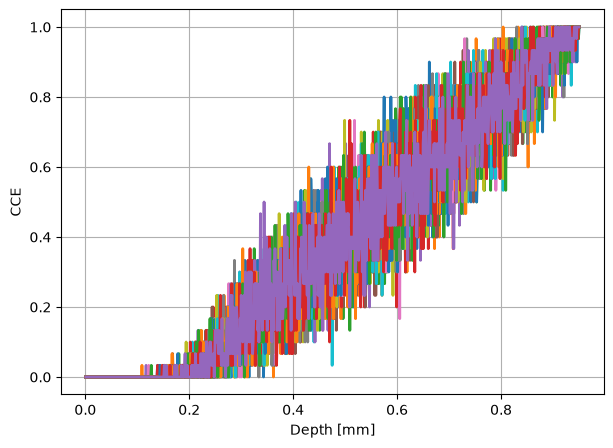

In [13]:


plt.figure(figsize=(7,5))

plt.plot(
    library.depth_mm,
    library.cce,
    lw=2
)

plt.xlabel("Depth [mm]")
plt.ylabel("CCE")
plt.grid()

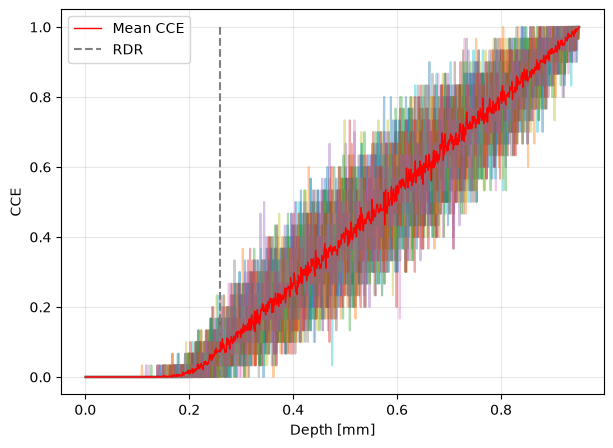

In [71]:
cce_mean = np.mean(
    library.cce,
    axis=1
)

plt.figure(figsize=(7,5))

plt.plot(
    library.depth_mm,
    cce_mean,
    lw=1,
    color = 'red',
    label="Mean CCE",
    zorder = 10
)


for r in range(library.cce.shape[1]):

    plt.plot(
        library.depth_mm,
        library.cce[:,r],
        alpha=0.4
    )

plt.vlines(0.26, 0, 1, color = 'grey', ls = '--',  label = "RDR")
plt.xlabel("Depth [mm]")
plt.ylabel("CCE")
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

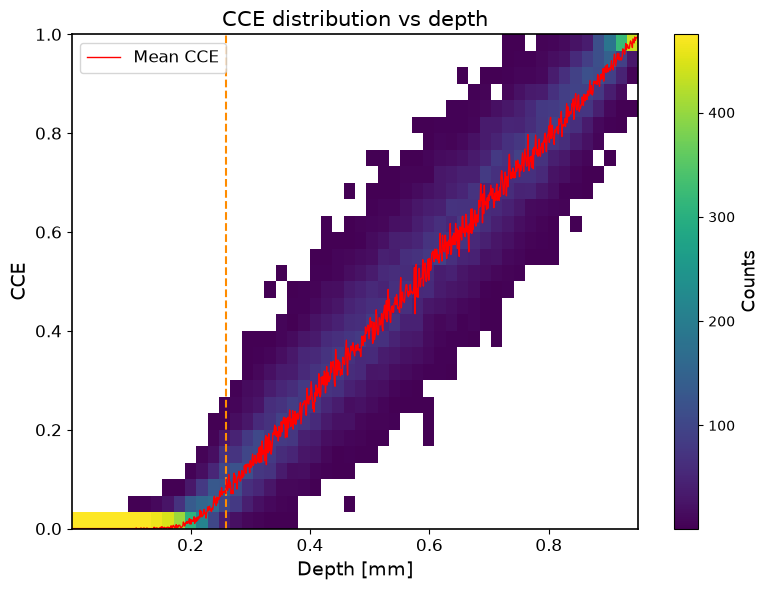

In [72]:

# forza stile bianco
plt.style.use("default")


# ==========================
# Prepare data
# ==========================

depth = np.repeat(
    library.depth_mm,
    library.cce.shape[1]
)

cce_values = library.cce.flatten()



# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(
    figsize=(8,6),
    facecolor="white"
)


ax.set_facecolor("white")


cmap = plt.cm.viridis.copy()
cmap.set_under("white")


h = ax.hist2d(
    depth,
    cce_values,
    bins=(50,30),
    cmap=cmap,
    vmin=1
)

h[3].set_clim(1, None)

# colorbar

cbar = fig.colorbar(
    h[3],
    ax=ax
)

cbar.set_label(
    "Counts",
    fontsize=13
)



# ==========================
# Mean CCE
# ==========================

cce_mean = np.mean(
    library.cce,
    axis=1
)

cce_std = np.std(
    library.cce,
    axis=1
)


ax.errorbar(
    library.depth_mm,
    cce_mean,
    #yerr = cce_std,
    color="red",
    lw=1,
    label="Mean CCE"
)



# ==========================
# Labels
# ==========================

ax.set_xlabel(
    "Depth [mm]",
    fontsize=14
)

ax.set_ylabel(
    "CCE",
    fontsize=14
)


ax.set_title(
    "CCE distribution vs depth",
    fontsize=15
)



# ==========================
# Style
# ==========================

ax.tick_params(
    labelsize=12
)


ax.legend(
    fontsize=12,
    frameon=True
)


for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.vlines(0.26, 0, 1, color = 'darkorange', ls = '--',  label = "RDR")

plt.tight_layout()

plt.show()


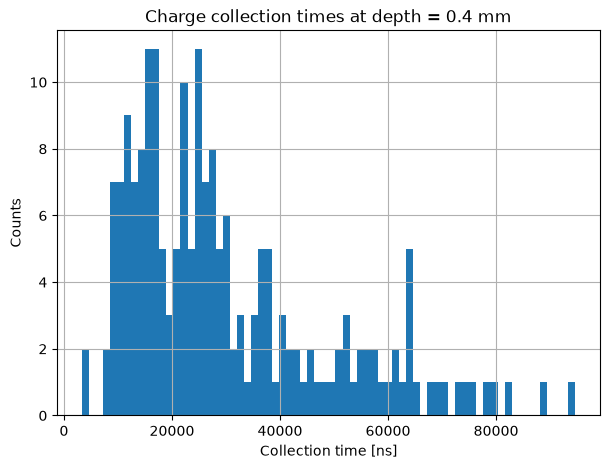

In [36]:
# profondità che vuoi analizzare
x0 = 0.4  # mm

# tolleranza perché i float possono non essere identici
tol = 1e-8

mask = (
    np.abs(history.depth_mm - x0) < tol
) & history.collected


times = history.lifetime_ns[mask]


plt.figure(figsize=(7,5))

plt.hist(
    times,
    bins=70,
    #range = (0,100000)
)

plt.xlabel("Collection time [ns]")
plt.ylabel("Counts")
plt.title(f"Charge collection times at depth = {x0} mm")

plt.grid()
plt.show()

(array([63480., 26557., 20498., 17319., 15042., 13465., 12067., 10784.,
         9815.,  8855.,  7934.,  7142.,  6543.,  5976.,  5248.,  4793.,
         4342.,  4068.,  3677.,  3226.,  2983.,  2661.,  2321.,  2136.,
         2047.,  1789.,  1655.,  1446.,  1267.,  1162.,   966.,   956.,
          865.,   771.,   733.,   627.,   640.,   566.,   514.,   444.,
          363.,   349.,   307.,   303.,   279.,   224.,   205.,   181.,
          188.,   171.]),
 array([    0.  ,  1999.66,  3999.32,  5998.98,  7998.64,  9998.3 ,
        11997.96, 13997.62, 15997.28, 17996.94, 19996.6 , 21996.26,
        23995.92, 25995.58, 27995.24, 29994.9 , 31994.56, 33994.22,
        35993.88, 37993.54, 39993.2 , 41992.86, 43992.52, 45992.18,
        47991.84, 49991.5 , 51991.16, 53990.82, 55990.48, 57990.14,
        59989.8 , 61989.46, 63989.12, 65988.78, 67988.44, 69988.1 ,
        71987.76, 73987.42, 75987.08, 77986.74, 79986.4 , 81986.06,
        83985.72, 85985.38, 87985.04, 89984.7 , 91984.36, 93984.02

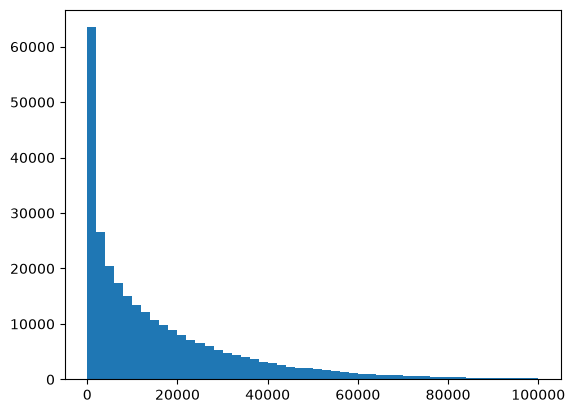

In [43]:
mask = history.collected

plt.hist(
    history.lifetime_ns[mask],
    bins=50
)
plt.ylabel('counts')
plt.xlabel('time (ns)')

(array([1.86659e+05, 2.09910e+04, 1.53630e+04, 1.27530e+04, 1.09330e+04,
        9.80700e+03, 9.07100e+03, 8.26000e+03, 7.79100e+03, 7.41200e+03,
        7.04500e+03, 6.63700e+03, 6.10800e+03, 5.86200e+03, 5.66400e+03,
        5.16600e+03, 5.04700e+03, 4.75600e+03, 4.64100e+03, 4.31600e+03,
        4.12300e+03, 3.98600e+03, 3.70400e+03, 3.47900e+03, 3.39900e+03,
        3.14600e+03, 2.97900e+03, 2.91000e+03, 2.64200e+03, 2.57500e+03,
        2.52100e+03, 2.24400e+03, 2.27200e+03, 2.21400e+03, 2.05200e+03,
        2.04300e+03, 1.86100e+03, 1.76200e+03, 1.66200e+03, 1.54300e+03,
        1.48000e+03, 1.39800e+03, 1.36300e+03, 1.30200e+03, 1.26900e+03,
        1.12000e+03, 1.06600e+03, 1.07500e+03, 1.05500e+03, 1.01000e+03,
        9.49000e+02, 8.87000e+02, 8.08000e+02, 7.95000e+02, 7.56000e+02,
        7.44000e+02, 6.32000e+02, 6.04000e+02, 6.33000e+02, 5.90000e+02,
        5.17000e+02, 5.09000e+02, 4.73000e+02, 4.42000e+02, 4.90000e+02,
        4.29000e+02, 4.15000e+02, 4.11000e+02, 3.58

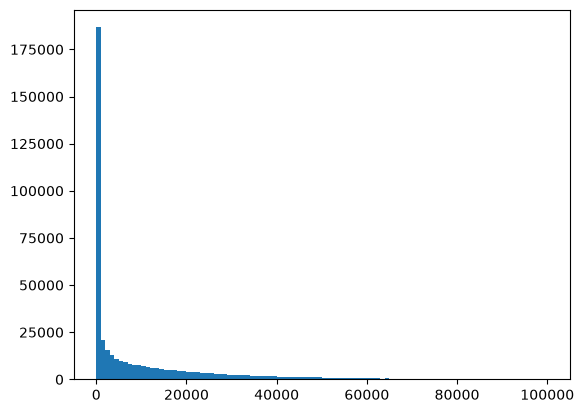

In [44]:
mask = history.trapped

plt.hist(
    history.lifetime_ns[mask],
    bins=100
)